# 3. Convolutional neural networks

## Importing Libraries

In this section, we import all necessary libraries for data handling, preprocessing, model building, and visualization.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras import models, layers

from sklearn.model_selection import train_test_split

## Loading the CIFAR-10 Dataset

We load the CIFAR-10 dataset directly from Keras. The dataset consists of 60k 32x32 color images in 10 classes.

In [46]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


## Creating a Validation Set

The training data is split into training and validation sets. The validation set is used to monitor model performance during training.

In [47]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42
)

## Preprocessing the Data

We preprocess the images using the preprocessing function corresponding to VGG16. This ensures compatibility with the pretrained model.

In [48]:
x_train = preprocess_input(x_train)
x_val = preprocess_input(x_val)
x_test = preprocess_input(x_test)

## Encoding Labels

The class labels are converted into one-hot encoded vectors for multiclass classification.

In [49]:
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

## Loading the Pretrained VGG16 Model

We load a pretrained VGG16 model without the final classification layers. The earlier layers are kept unchanged so their learned weights are not updated during training.

In [50]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

conv_base.trainable = False

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Feature Extraction Function

This function uses the pretrained convolutional base to extract features from the images. These features will serve as input to the classifier.

In [51]:
def extract_features(data, conv_base):
    return conv_base.predict(data, batch_size=32, verbose=1)

## Extracting Features

We pass the training, validation, and test data through the convolutional base to obtain feature representations.

In [52]:
x_train_feat = extract_features(x_train, conv_base)
x_val_feat = extract_features(x_val, conv_base)
x_test_feat = extract_features(x_test, conv_base)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 123s 98ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step


## Flattening Features

The extracted features are turned into a flat vector so they can be used as input for the classifier.

In [53]:
x_train_feat = x_train_feat.reshape(len(x_train_feat), -1)
x_val_feat = x_val_feat.reshape(len(x_val_feat), -1)
x_test_feat = x_test_feat.reshape(len(x_test_feat), -1)

print("Feature shape:", x_train_feat.shape)

Feature shape: (40000, 512)


## Building the Classifier

We build a simple neural network with one hidden layer and use dropout to help prevent overfitting.

In [54]:
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(x_train_feat.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,898 (523.04 KB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

The classifier is trained using the extracted features. Validation data is used to monitor performance and detect overfitting.

In [55]:
history = model.fit(
    x_train_feat, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val_feat, y_val)
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4326 - loss: 3.1518 - val_accuracy: 0.5674 - val_loss: 1.2579
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5350 - loss: 1.3501 - val_accuracy: 0.6110 - val_loss: 1.1327
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5797 - loss: 1.2177 - val_accuracy: 0.6165 - val_loss: 1.0861
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6076 - loss: 1.1310 - val_accuracy: 0.6395 - val_loss: 1.0543
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6232 - loss: 1.0822 - val_accuracy: 0.6469 - val_loss: 1.0412
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6352 - loss: 1.0444 - val_accuracy: 0.6516 - val_loss: 1.0292
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6410 - loss: 1.0228 - val_accuracy: 0.6575 - val_loss: 1.0185
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6504 - loss: 0.9954 - val_accuracy: 0.

## Training and Validation Metrics

We visualize both accuracy and loss during training for the training and validation sets to see how the model is learning and to check for overfitting.

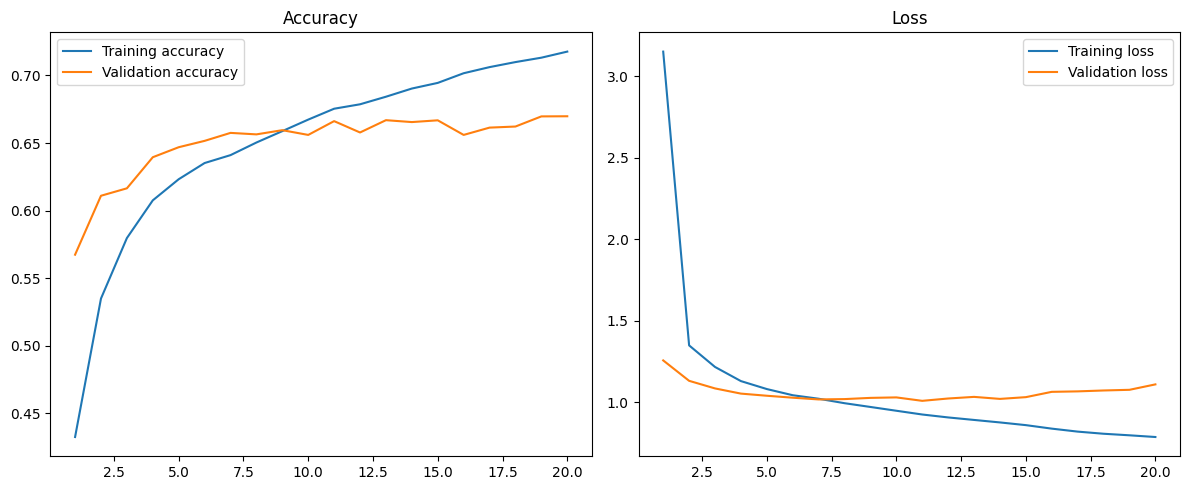

In [60]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation

Finally, we test the trained model on new data to see how well it performs.

In [58]:
test_loss, test_acc = model.evaluate(x_test_feat, y_test)

print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6604 - loss: 1.1439
Test accuracy: 0.6603999733924866


## Hyperparameter Tuning

We tested different settings to improve the model’s performance:

- Dense layer size: 128 or 256 units  
- Dropout rate: 0.3 or 0.5  
- Number of training epochs: 10 or 20  

The best results were achieved with:
- 256 units in the dense layer  
- Dropout rate of 0.5  
- 20 training epochs  

These settings were used in the final model.

## Results and Discussion

The model achieved a test accuracy of about 66%.

The results:
- CIFAR-10 images are small (32×32 pixels)
- The VGG16 model was trained on larger images (224×224)
- The convolutional base was not fine-tuned

### Observations
- Training accuracy increases steadily
- Validation accuracy levels off, showing limited generalization
- Dropout helps reduce overfitting